### EDA :
  A short Understanding of Data before starting the Dashboard.

In [12]:
# --- import libreries ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)

In [13]:
# --- import dataset ---
df = pd.read_csv('final_mcdonalds_menu.csv')
df.head()

,item_name,category,price_usd,calories,calories_from_fat,total_fat_g,saturated_fat_g,trans_fat_g,cholesterol_mg,sodium_mg,total_carbs_g,dietary_fiber_g,sugars_g,protein_g,calcium_mg,iron_mg,vitamin_a_iu,vitamin_c_mg,is_vegetarian,is_limited_time,is_nationwide,prep_time_minutes
0,Big Mac,Burgers,6.55,530,177,27,8.9,1.6,69,924,45,2.6,10.2,26,15,0.3,29,16,False,False,True,2
1,Quarter Pounder with Cheese,Burgers,7.03,515,188,26,8.6,3.8,43,1077,41,2.5,8.8,31,183,2.5,77,8,False,False,True,5
2,Cheeseburger,Burgers,6.81,291,113,13,6.1,1.8,48,695,31,2.4,9.0,16,186,0.5,45,6,False,False,True,4
3,Double Cheeseburger,Burgers,5.84,448,156,23,8.4,2.9,7,1133,36,2.6,3.9,26,161,1.2,8,6,False,False,True,4
4,McDouble,Burgers,5.05,397,86,21,9.4,1.9,74,906,35,3.1,5.8,23,70,1.5,11,24,False,False,True,9


In [45]:
display(df.describe())
print(df.columns)

,price_usd,calories,calories_from_fat,total_fat_g,saturated_fat_g,trans_fat_g,cholesterol_mg,sodium_mg,total_carbs_g,dietary_fiber_g,sugars_g,protein_g,calcium_mg,iron_mg,vitamin_a_iu,vitamin_c_mg,prep_time_minutes
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.00000,80.000000,80.000000,80.0000,80.000000,80.000000,80.00000,80.000000,80.000000,80.000000,80.00000
mean,4.084000,312.512500,111.525000,13.812500,5.588750,1.280000,42.90000,463.712500,35.812500,3.5800,8.496250,11.362500,149.72500,1.277500,51.275000,14.187500,6.15000
std,1.723629,179.687915,68.027912,10.887333,4.643056,1.082356,23.16512,442.537281,21.150512,2.5464,6.207355,9.401379,80.95568,0.897109,31.470692,8.344017,2.64862
min,1.190000,3.000000,0.000000,0.000000,0.000000,0.000000,3.00000,0.000000,0.000000,0.0000,0.000000,0.000000,10.00000,0.000000,1.000000,1.000000,2.00000
25%,2.622500,162.250000,63.000000,5.000000,2.000000,0.400000,19.00000,89.750000,23.750000,1.8750,3.875000,4.750000,76.75000,0.500000,23.500000,7.750000,4.00000
50%,3.980000,295.000000,99.500000,11.000000,4.900000,1.100000,45.00000,263.500000,35.000000,3.2000,6.600000,9.500000,153.50000,1.200000,52.500000,13.000000,7.00000
75%,5.325000,454.000000,158.250000,22.250000,8.500000,1.725000,62.00000,772.250000,44.250000,4.6000,12.625000,17.000000,210.50000,2.000000,81.000000,20.250000,9.00000
max,7.700000,783.000000,373.000000,48.000000,22.700000,4.900000,80.00000,1459.000000,93.000000,12.5000,27.700000,48.000000,284.00000,3.000000,100.000000,30.000000,10.00000


Index(['item_name', 'category', 'price_usd', 'calories', 'calories_from_fat',
       'total_fat_g', 'saturated_fat_g', 'trans_fat_g', 'cholesterol_mg',
       'sodium_mg', 'total_carbs_g', 'dietary_fiber_g', 'sugars_g',
       'protein_g', 'calcium_mg', 'iron_mg', 'vitamin_a_iu', 'vitamin_c_mg',
       'is_vegetarian', 'is_limited_time', 'is_nationwide',
       'prep_time_minutes'],
      dtype='object')


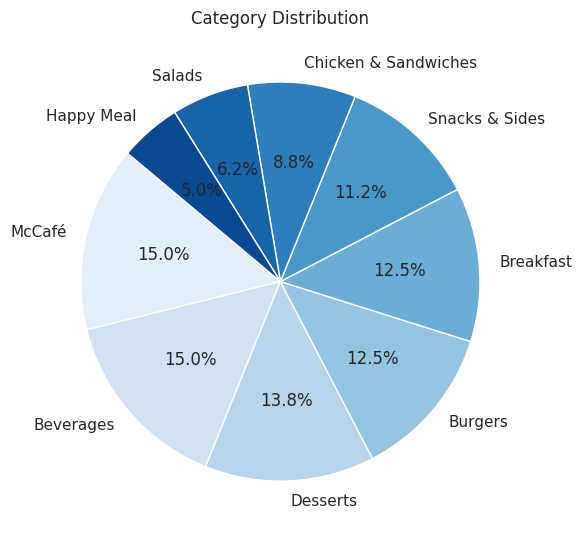

In [24]:
# --- distribution ---
category_counts = df['category'].value_counts()
blue_palette = sns.color_palette("Blues", len(category_counts))

plt.figure(figsize=(6, 6))
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=blue_palette
)
plt.title('Category Distribution')
plt.tight_layout()
plt.show()

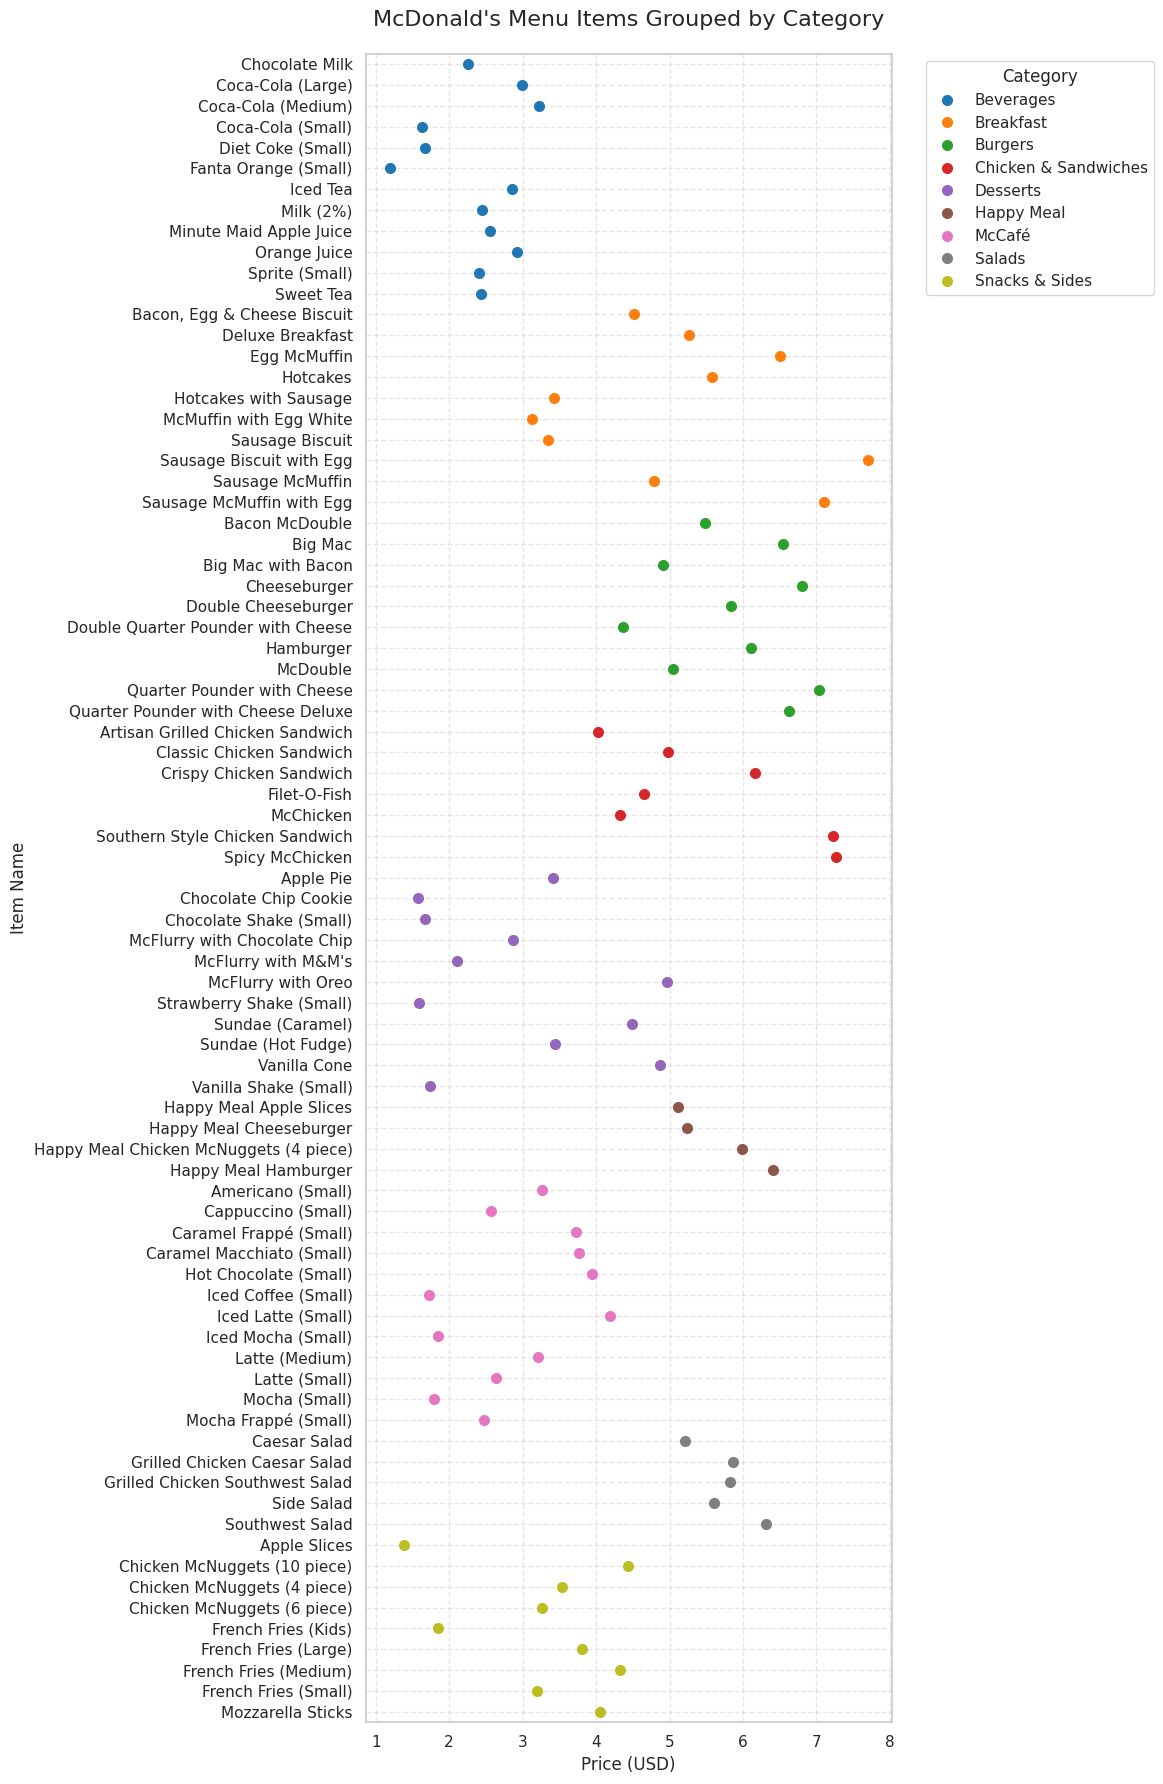

In [34]:
# --- product by category ---
plt.figure(figsize=(12, 18))

# Sort the dataframe by category and item_name for a clean presentation
df_sorted = df.sort_values(by=['category', 'item_name'])

# Create a horizontal strip plot showing items grouped by category
sns.stripplot(
    data=df_sorted,
    x='price_usd',
    y='item_name',
    hue='category',
    palette='tab10',
    size=8,
    dodge=False
)

plt.title('McDonald\'s Menu Items Grouped by Category', fontsize=16, pad=20)
plt.xlabel('Price (USD)', fontsize=12)
plt.ylabel('Item Name', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Average Price by Category'}, ylabel='category'>

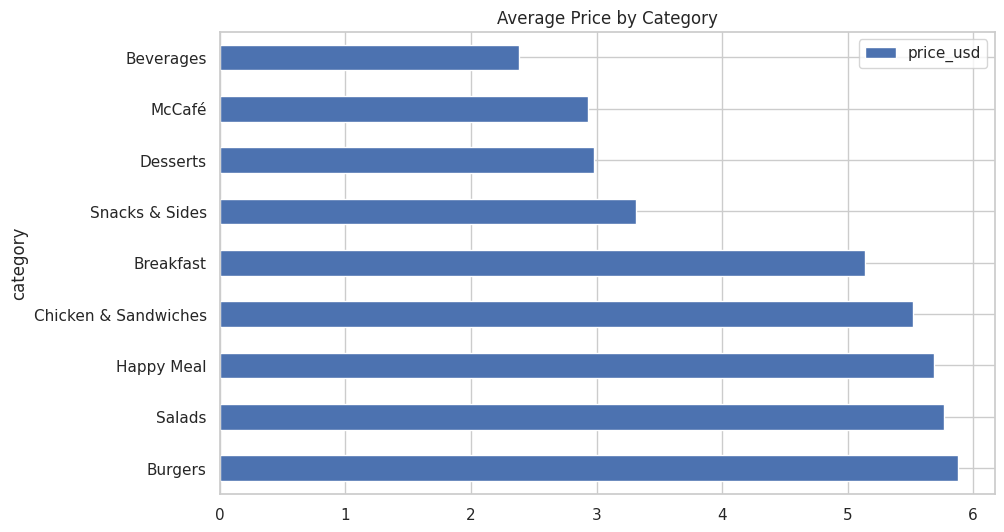

In [33]:
# --- category by average price ---
df.groupby('category')['price_usd'].mean().reset_index().sort_values(by='price_usd', ascending=False).plot(kind='barh', x='category', y='price_usd', title='Average Price by Category')

In [40]:
# --- max and min price produxt ---
display(df[df['price_usd'] == max(df['price_usd'])][['category', 'item_name', 'price_usd']])
display(df[df['price_usd'] == min(df['price_usd'])][['category', 'item_name', 'price_usd']])

,category,item_name,price_usd
36,Breakfast,Sausage Biscuit with Egg,7.7


,category,item_name,price_usd
46,Beverages,Fanta Orange (Small),1.19


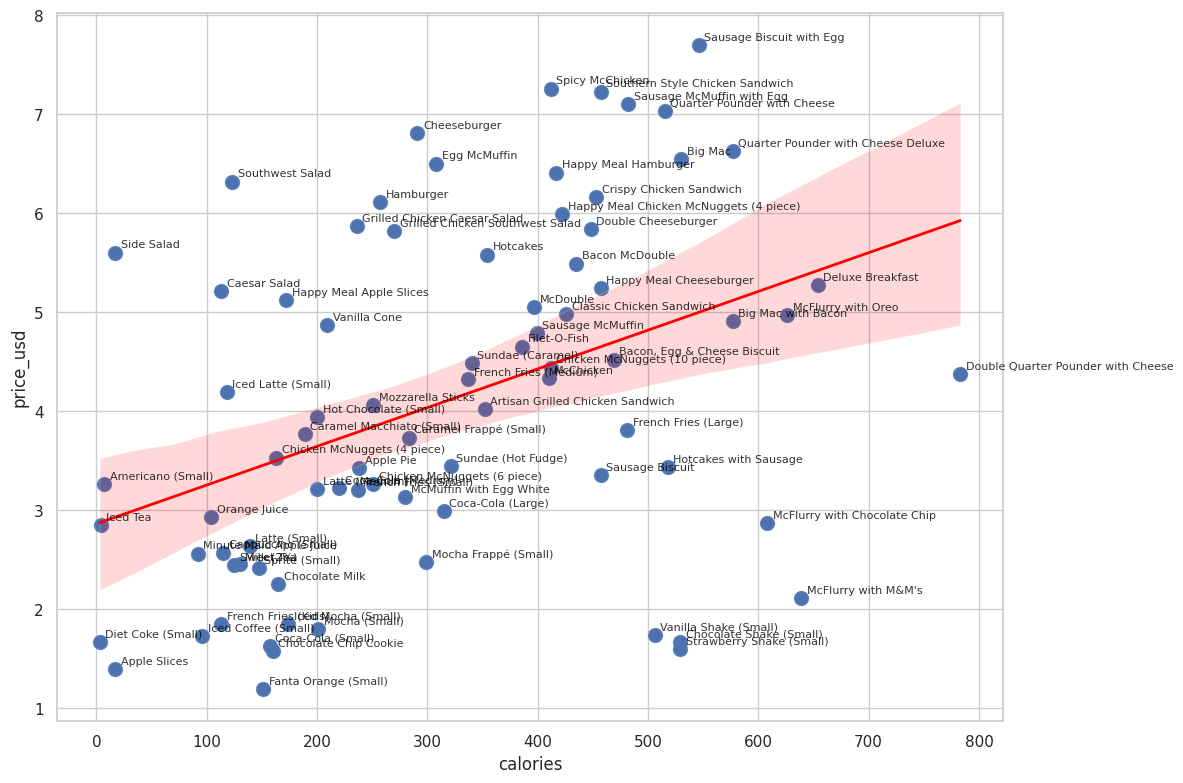

In [50]:
# --- comparing price by calories with item names annotated ---
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='calories', y='price_usd', s=100)

sns.regplot(
    data=df,
    x='calories',
    y='price_usd',
    scatter_kws={'s': 100},
    line_kws={'color': 'red', 'lw': 2}
)

for index, row in df.iterrows():
    plt.text(
        x=row['calories'] + 5,
        y=row['price_usd'] + 0.05,
        s=row['item_name'],
        fontdict=dict(color='black', alpha=0.8, size=8)
    )
plt.tight_layout()
plt.show()

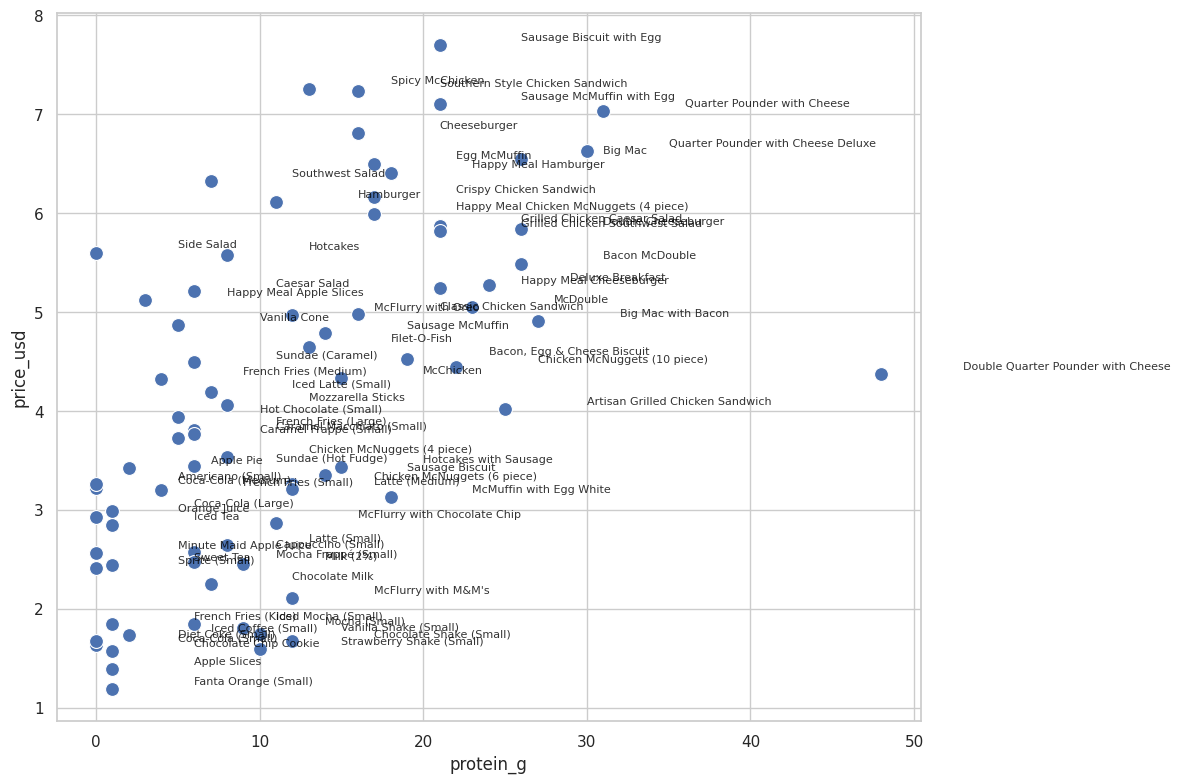

In [54]:
# --- comparing price by calories with item names annotated ---
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='protein_g', y='price_usd', s=100)


for index, row in df.iterrows():
    plt.text(
        x=row['protein_g'] + 5,
        y=row['price_usd'] + 0.05,
        s=row['item_name'],
        fontdict=dict(color='black', alpha=0.8, size=8)
    )
plt.tight_layout()
plt.show()

by ploting calory with price I found out that double quater pounder with cheese in comes under mid rance price but provides max calories. other then some outliers the calory and price plot is a straight line and protean also follow the similar trend.

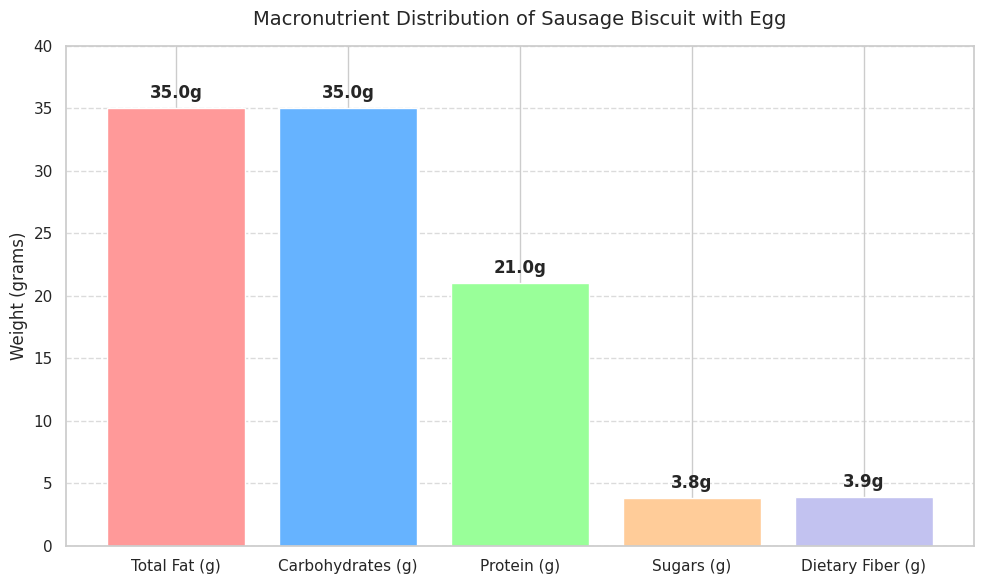

,item_name,calories,total_fat_g,total_carbs_g,protein_g,sodium_mg,cholesterol_mg
36,Sausage Biscuit with Egg,546,35,35,21,1265,41


In [55]:
# --- Nutritional distribution for 'Sausage Biscuit with Egg' ---
item_df = df[df['item_name'] == 'Sausage Biscuit with Egg']

if not item_df.empty:
    # Extract nutritional metrics (converting mg to g for sodium/cholesterol if we want a unified scale,
    # or plotting them as a percentage of daily value, or displaying their raw values in a bar plot).
    # Let's create a clear bar plot of the main macronutrients in grams.
    row = item_df.iloc[0]

    nutrients = {
        'Total Fat (g)': row['total_fat_g'],
        'Carbohydrates (g)': row['total_carbs_g'],
        'Protein (g)': row['protein_g'],
        'Sugars (g)': row['sugars_g'],
        'Dietary Fiber (g)': row['dietary_fiber_g']
    }

    plt.figure(figsize=(10, 6))
    bars = plt.bar(nutrients.keys(), nutrients.values(), color=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'])

    # Add value labels on top of the bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"{yval}g", ha='center', va='bottom', fontweight='bold')

    plt.title('Macronutrient Distribution of Sausage Biscuit with Egg', fontsize=14, pad=15)
    plt.ylabel('Weight (grams)', fontsize=12)
    plt.ylim(0, max(nutrients.values()) + 5)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Display a small summary table containing micro-nutrients as well
    display(item_df[['item_name', 'calories', 'total_fat_g', 'total_carbs_g', 'protein_g', 'sodium_mg', 'cholesterol_mg']])
else:
    print("Item 'Sausage Biscuit with Egg' not found in dataset.")

<Axes: xlabel='is_nationwide', ylabel='count'>

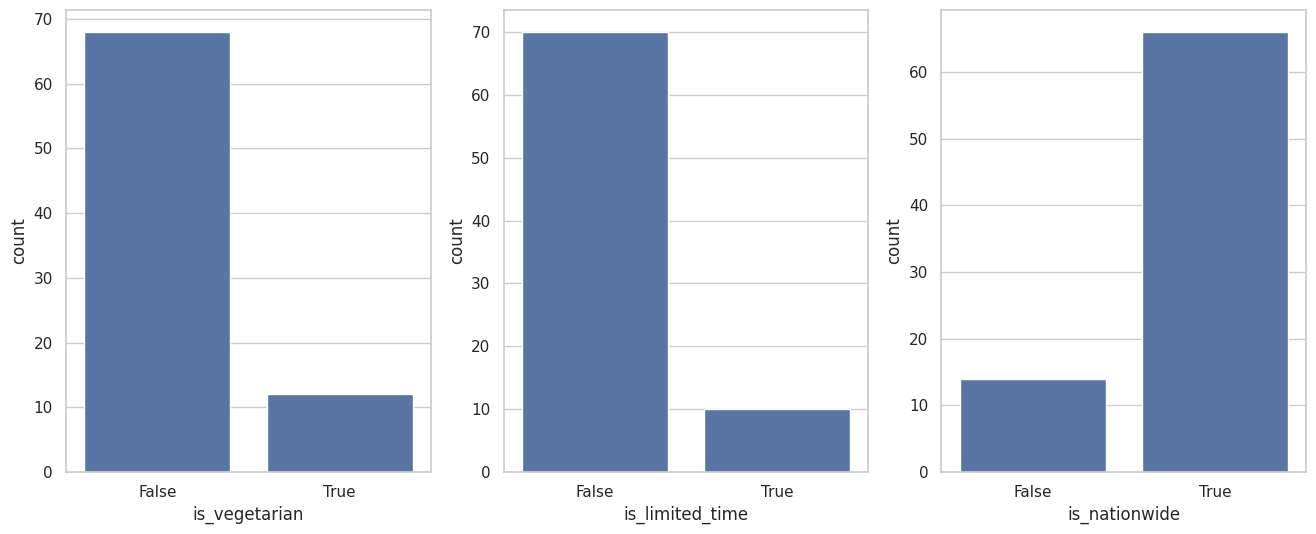

In [59]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='is_vegetarian')

plt.subplot(1, 3, 2)
sns.countplot(data=df, x='is_limited_time')

plt.subplot(1, 3, 3)
sns.countplot(data=df, x='is_nationwide')

In [64]:
# --- deducing unhealthy fat and the unhealthist food ---
df['unsaturated_fat_g'] = df['total_fat_g'] - df['saturated_fat_g'] - df['trans_fat_g']

df[df['unsaturated_fat_g'] == max(df['unsaturated_fat_g'])]

,item_name,category,price_usd,calories,calories_from_fat,total_fat_g,saturated_fat_g,trans_fat_g,cholesterol_mg,sodium_mg,total_carbs_g,dietary_fiber_g,sugars_g,protein_g,calcium_mg,iron_mg,vitamin_a_iu,vitamin_c_mg,is_vegetarian,is_limited_time,is_nationwide,prep_time_minutes,unsaturated_fat_g
9,Double Quarter Pounder with Cheese,Burgers,4.37,783,373,48,22.7,2.7,12,1459,44,2.5,14.0,48,55,0.7,24,17,False,False,True,10,22.6


THats enough for data understanding